Number of Conformers: 615
NaNs: False, Infs: True


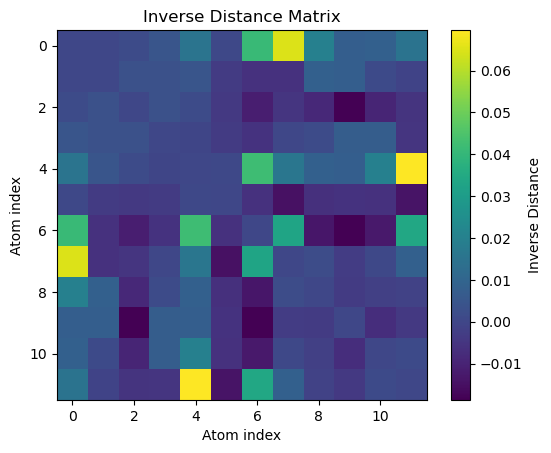

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

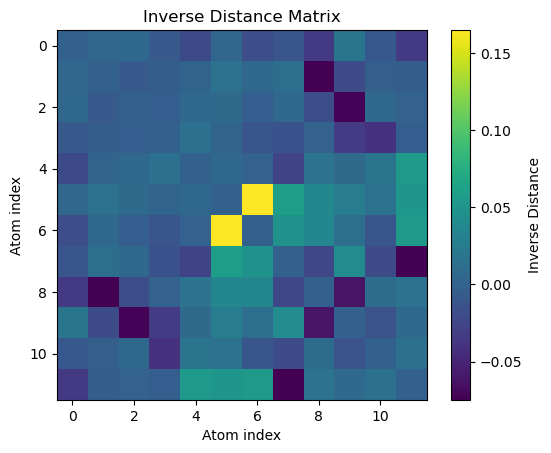

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

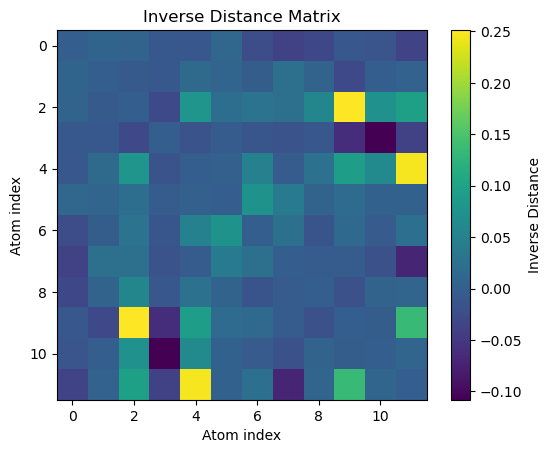

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem, GetPeriodicTable

from rapiat.geometry import (
    get_conformer_positions,
    inverse_distance_matrix,
)
from rapiat.util import assign_bonds_by_distance, read_xyz_conformers, remove_all_bonds

# Example usage:
mol = Chem.MolFromSmiles("c1ccccc1")  # Replace with your molecule
mol = read_xyz_conformers("../data/benzene_meci_seam.xyz", mol)
mol = remove_all_bonds(mol)
mol = assign_bonds_by_distance(mol)
print(f"Number of Conformers: {mol.GetNumConformers()}")

X = get_conformer_positions(mol)

masses = np.array(
    [GetPeriodicTable().GetAtomicWeight(atom.GetAtomicNum()) for atom in mol.GetAtoms()]
)
sqrt_masses = np.sqrt(masses)  # shape (n_atoms,)
X = X * sqrt_masses[:, None]  # broadcasts over coordinates

R = inverse_distance_matrix(X)
print(f"NaNs: {np.isnan(R).any()}, Infs: {np.isinf(R).any()}")
R[np.where(np.isinf(R))] = 0

for conformer_id in range(3):
    plt.imshow(((R - R.mean(axis=0))[conformer_id]), cmap="viridis")
    plt.colorbar(label="Inverse Distance")
    plt.title("Inverse Distance Matrix")
    plt.xlabel("Atom index")
    plt.ylabel("Atom index")
    plt.show()

    view = py3Dmol.view(width=300, height=300)
    mb = Chem.MolToMolBlock(mol, confId=conformer_id)
    view.addModel(mb, "mol")
    view.setStyle({"stick": {}})
    view.zoomTo()
    view.show()
# -> quadratic assignment problem to find the best permutation that matches two matrices

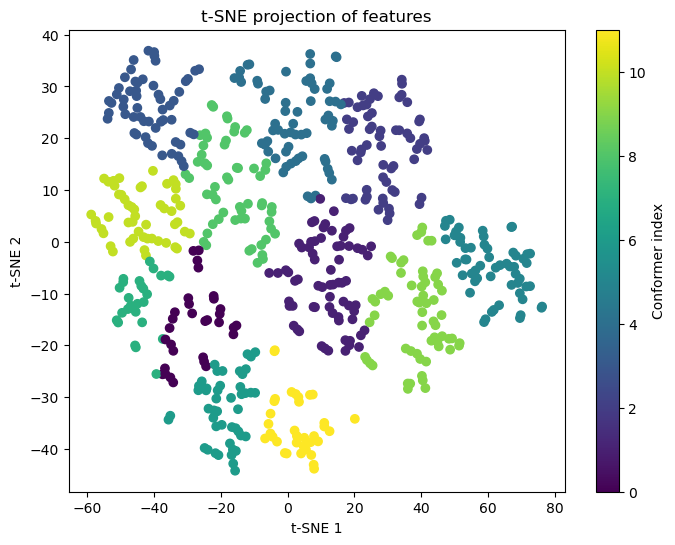

In [ ]:
from scipy.optimize import quadratic_assignment
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

dim1 = R.shape[1]


def permutation_invariant_metric(A, B):
    A = A.reshape(dim1, dim1)
    B = B.reshape(dim1, dim1)
    res = quadratic_assignment(A, B)
    perm = res["col_ind"]
    P = np.eye(len(A), dtype=int)[perm]
    return np.linalg.norm(A - P @ B @ P.T)


# plan coulomb matrix
# scaler = StandardScaler()
# features = scaler.fit_transform(R.reshape(R.shape[0], -1))  # Flatten the distance matrix for scaling
# features = (R - R.mean(axis=0)).reshape(R.shape[0], -1)

# singular values of coulomb matrix
features = []
for i in range(R.shape[0]):
    U, S, Vt = np.linalg.svd(R[i] - R[i].mean(axis=0), full_matrices=False)
    features.append(S)
features = np.array(features)

# Re-standardize the features (might not be intended)
# scaler = StandardScaler()
# features = scaler.fit_transform(features)  # Flatten the distance matrix for scaling

# # Run t-SNE (reduce to 2D for visualization)
tsne = TSNE(n_components=2, random_state=42, metric="euclidean", perplexity=10)
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, metric=permutation_invariant_metric)
features_tsne = tsne.fit_transform(features)  # Flatten the distance matrix for t-SNE

# Cluster the embedding (e.g., features_2d) with k-means++
n_clusters = 12  # Set the number of clusters you want
kmeans = KMeans(n_clusters=n_clusters, init="k-means++", random_state=42)
cluster_labels = kmeans.fit_predict(features_tsne)

plt.figure(figsize=(8, 6))
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=cluster_labels, cmap="viridis")
# plt.scatter(features_2d[:, 0], features_2d[:, 1], c=range(features_2d.shape[0]), cmap='viridis')
plt.colorbar(label="Conformer index")
plt.title("t-SNE projection of features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

/home/romanellerbrock/code/rapiat/.pixi/envs/dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/romanellerbrock/code/rapiat/.pixi/envs/dev/lib/python3.13/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/romanellerbrock/code/rapiat/.pixi/envs/dev/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


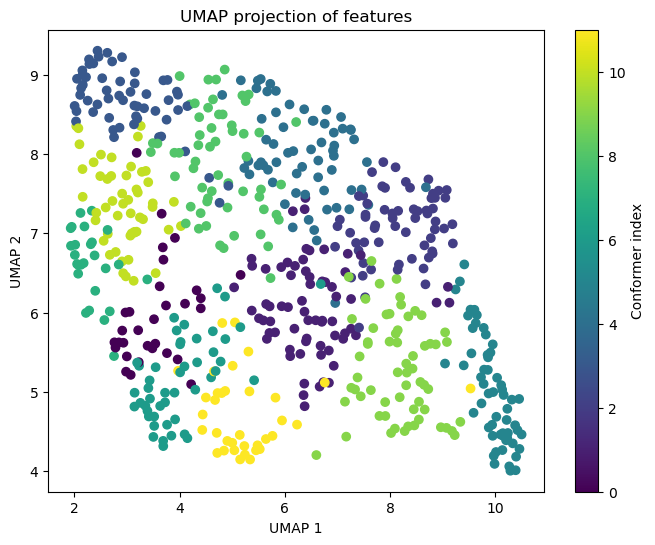

In [3]:
import umap

umap_model = umap.UMAP(n_components=2, random_state=42, min_dist=0.2, n_neighbors=25)
features_umap = umap_model.fit_transform(features)  # Flatten the distance matrix for UMAP

"""
NOTE: I leave this out, so you can check whether t-SNE & UMAP give the same clusters.
if set to True, it will run k-means++ on the UMAP features and use the assignments in the next cell.
"""
umat_kmeans_clusters = False
if umat_kmeans_clusters:
    kmeans = KMeans(n_clusters=n_clusters, init="k-means++", random_state=42)
    cluster_labels = kmeans.fit_predict(features_umap)

plt.figure(figsize=(8, 6))
plt.scatter(features_umap[:, 0], features_umap[:, 1], c=cluster_labels, cmap="viridis")
plt.colorbar(label="Conformer index")
plt.title("UMAP projection of features")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

In [4]:
import numpy as np

try:
    A = features.reshape(R.shape)
except:
    A = features

displayed_clusters = range(n_clusters)
# displayed_clusters=[7]

centroids = kmeans.cluster_centers_
closest_indices = []
for centroid in centroids:
    distances = np.linalg.norm(features_tsne - centroid, axis=1)
    closest_idx = np.argmin(distances)
    closest_indices.append(closest_idx)
print("Indices of data points closest to each centroid:", closest_indices)

# compute average distance matrix for each cluster
all_cluster_indices = []
for cluster in range(n_clusters):
    cluster_indices = np.where(cluster_labels == cluster)[0]
    avg_distance_matrix = np.mean(A[cluster_indices], axis=0)
    all_cluster_indices.append(cluster_indices)


for cluster in displayed_clusters:
    centroid = closest_indices[cluster]
    print(f"Cluster {cluster} with {len(all_cluster_indices[cluster])} conformers")
    print(f"Conformer {centroid} in cluster {cluster}")

    # plt.imshow((A[centroid]), cmap='viridis')
    # plt.colorbar(label='Inverse Distance')
    # plt.title('Inverse Distance Matrix')
    # plt.xlabel('Atom index')
    # plt.ylabel('Atom index')
    # plt.show()

    # plt.imshow(avg_distance_matrix, cmap='viridis')
    # plt.colorbar(label='Inverse Distance')
    # plt.title(f'Average Inverse Distance Matrix for Cluster {cluster}')
    # plt.xlabel('Atom index')
    # plt.ylabel('Atom index')
    # plt.show()

    view = py3Dmol.view(width=300, height=300)
    print(f"Centroid conformer: {centroid}")
    ref_conf = centroid  # use first conformer as reference
    mb = Chem.MolToMolBlock(mol, confId=int(centroid))
    view.addModel(mb, "mol")

    for conf_id in range(mol.GetNumConformers()):
        AllChem.AlignMol(mol, mol, prbCid=conf_id, refCid=int(ref_conf))

    for i in all_cluster_indices[cluster]:
        mb = Chem.MolToMolBlock(mol, confId=int(i))
        view.addModel(mb, "mol")

    view.setStyle({"stick": {}})
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetProp(
            "name", f"H{i + 1}" if atom.GetSymbol() == "H" else f"{atom.GetSymbol()}{i + 1}"
        )

    view.zoomTo()
    view.show()
    # -> quadratic assignment problem to find the best permutation that matches two matrices

Indices of data points closest to each centroid: [np.int64(453), np.int64(582), np.int64(29), np.int64(278), np.int64(448), np.int64(303), np.int64(76), np.int64(506), np.int64(31), np.int64(236), np.int64(36), np.int64(33)]
Cluster 0 with 31 conformers
Conformer 453 in cluster 0
Centroid conformer: 453


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Cluster 1 with 68 conformers
Conformer 582 in cluster 1
Centroid conformer: 582


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Cluster 2 with 62 conformers
Conformer 29 in cluster 2
Centroid conformer: 29


...

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Cluster 10 with 51 conformers
Conformer 36 in cluster 10
Centroid conformer: 36


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Cluster 11 with 35 conformers
Conformer 33 in cluster 11
Centroid conformer: 33


3Dmol.js failed to load for some reason. Please check your browser console for error messages.